### Import Libraries

In [1]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# Statistics.
import scipy.stats as stats

# Data frames.
import pandas as pd

# Statistical plots.
import seaborn as sns

from scipy.stats import norm

### Task 1: Permutations and Combinations

In [2]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
no_cups_milk_first = 6

# Number of cups of tea with tea in first.
no_cups_tea_first = 6

In [3]:
# Number of ways of selecting four cups from eight.
ways = math.comb(no_cups, no_cups_milk_first)

# Show.
ways

924

### Task 2: numpy's Normal Distribution

In [4]:
sample = np.random.normal(10, 3, 100000)

In [5]:
stats.shapiro(sample)

c:\Users\Fujitsu\anaconda3\lib\site-packages\scipy\stats\_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.9999650120735168, pvalue=0.4260613024234772)

(array([1.1000e+01, 3.0800e+02, 3.2800e+03, 1.5427e+04, 3.2695e+04,
        3.1244e+04, 1.4077e+04, 2.6960e+03, 2.4800e+02, 1.4000e+01]),
 array([-3.66264756, -0.90352708,  1.8555934 ,  4.61471389,  7.37383437,
        10.13295485, 12.89207534, 15.65119582, 18.4103163 , 21.16943679,
        23.92855727]),
 <BarContainer object of 10 artists>)

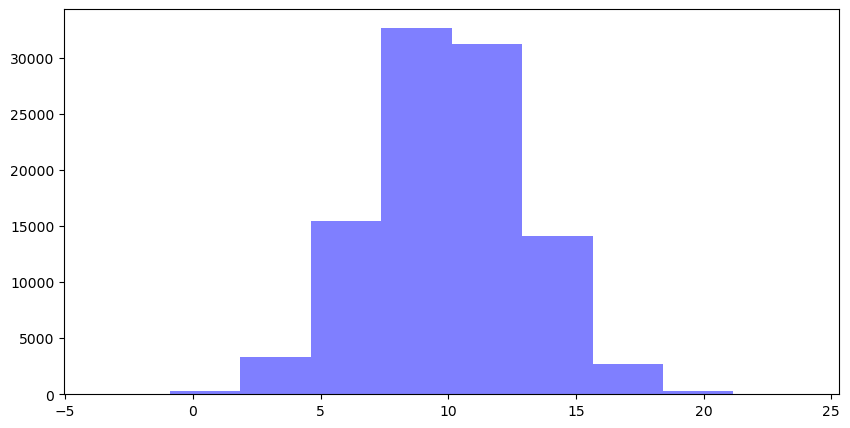

In [6]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(sample, color='blue', alpha=0.5, label='Sample')

(array([9.06085840e-06, 4.53042920e-05, 1.54034593e-04, 6.34260088e-04,
        2.04775400e-03, 5.69927993e-03, 1.30204535e-02, 2.70013580e-02,
        4.87292965e-02, 7.50510901e-02, 1.04607610e-01, 1.25048907e-01,
        1.30739126e-01, 1.19503661e-01, 9.94429209e-02, 7.04572349e-02,
        4.37730069e-02, 2.25796591e-02, 1.10995515e-02, 4.06832542e-03,
        1.54034593e-03, 6.25199229e-04, 1.44973734e-04, 4.53042920e-05,
        1.81217168e-05]),
 array([-3.66264756, -2.55899937, -1.45535118, -0.35170298,  0.75194521,
         1.8555934 ,  2.9592416 ,  4.06288979,  5.16653798,  6.27018618,
         7.37383437,  8.47748256,  9.58113076, 10.68477895, 11.78842714,
        12.89207534, 13.99572353, 15.09937172, 16.20301992, 17.30666811,
        18.4103163 , 19.5139645 , 20.61761269, 21.72126088, 22.82490908,
        23.92855727]),
 <BarContainer object of 25 artists>)

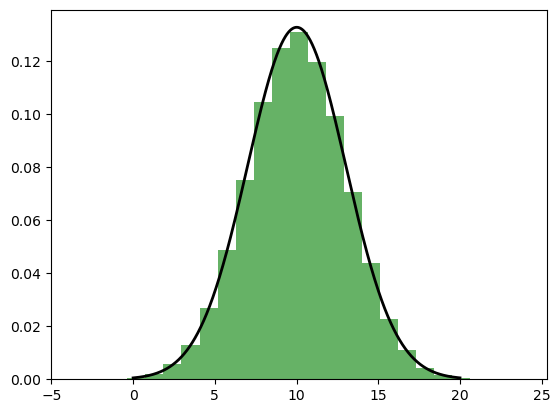

In [7]:
mu, std = norm.fit(sample)
x = np.linspace(0, 20, 1001)
p = norm.pdf(x, mu, std)
fig, ax = plt.subplots(1, 1) 
plt.plot(x, p, 'k', linewidth=2)
#ax.hist(sample, color='blue', alpha=0.5, label='Sample')
plt.hist(sample, bins=25, density=True, alpha=0.6, color='g')

### Task 3: t-Test Calculation

In [8]:
Before = [63,68,70,64,74,67,70,57,66,65]

In [9]:
After = [64,64,68,64,73,70,72,54,61,63]

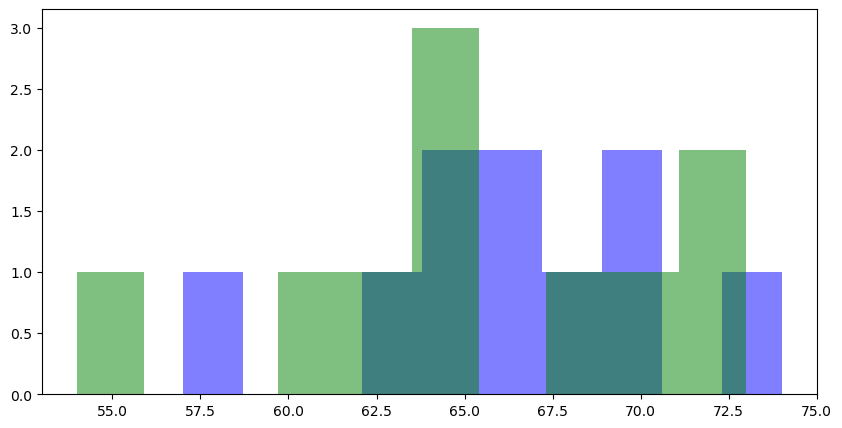

In [10]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(Before, color='blue', alpha=0.5, label='Before')

# Create histogram.
ax.hist(After, color='green', alpha=0.5, label='After');

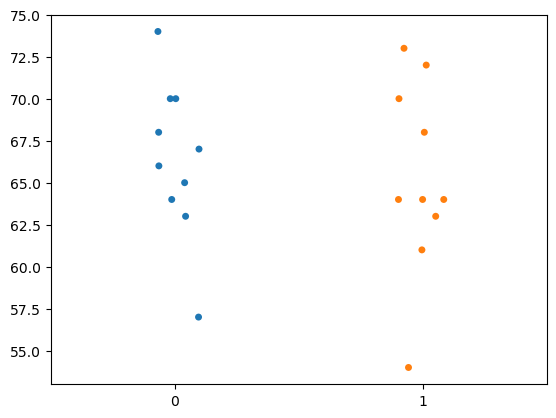

In [11]:
# Create a strip plot.
sns.stripplot(data=[Before, After]);

In [12]:
stats.ttest_ind(Before, After)

Ttest_indResult(statistic=0.4740968275126808, pvalue=0.6411310132871086)

In [13]:
n = len(Before)
n
zipped_lists = zip(Before, After)
zipped_lists
numerator = [x - y for (x, y) in zipped_lists]
numerator
sum (numerator)
dem = [((y - x)**2) for (x, y) in zipped_lists]
dem
sum(dem)
dem = [((Before[i]-After[i])**2) for i in range(len(After))]
sum(dem)

73

In [14]:
def t_statistic(Before, After):
    n = len(Before)
    #numerator = sum(Before - After)
    #numerator = list(np.array(Before) - np.array(After))
    zipped_lists = zip(Before, After) 
    numerator = [x - y for (x, y) in zipped_lists]
    numerator = sum(numerator)
    dem = [((Before[i]-After[i])**2) for i in range(len(After))]
    s = sum(dem)/(n - 1)
    return numerator/(s/np.sqrt(n))

In [15]:
t_statistic(Before, After)

4.288568333653008

In [16]:
stats.ttest_rel(Before, After)

Ttest_relResult(statistic=1.337227482480628, pvalue=0.21396011317404623)

### Task 4: ANOVA

In [17]:
no_type_ii = 0

In [18]:
# First sample.
sample_a = np.random.normal(loc=4.9, scale=0.1, size=100)

# Second sample.
sample_b = np.random.normal(loc=5.0, scale=0.1, size=100)

# Third sample.
sample_c = np.random.normal(loc=5.1, scale=0.1, size=100)

In [19]:
# Create data frame.
df = pd.DataFrame({'Sample_a': sample_a, 'Sample_b': sample_b, 'Sample_c': sample_c})

# Show.
df

,Sample_a,Sample_b,Sample_c
0,4.943655,5.140689,5.019396
1,4.934644,5.104011,4.992518
2,4.804390,4.923866,4.963236
3,5.002390,4.986610,5.231816
4,4.922850,5.090006,5.031032
...,...,...,...
95,4.983953,4.978962,5.140407
96,4.893014,4.906648,5.149758
97,4.823327,4.792932,5.109652
98,5.091779,5.026126,5.072141


In [20]:
# Perform ANOVA.
f_statistic, p_value = stats.f_oneway(df['Sample_a'], df['Sample_b'], df['Sample_c'])

# Show.
f_statistic, p_value

(114.86972275707599, 1.1151932993949995e-37)

In [21]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Sample_a'], df['Sample_b'], df['Sample_c'])

# Show.
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.101     0.000    -0.134    -0.069
 (0 - 2)     -0.209     0.000    -0.241    -0.176
 (1 - 0)      0.101     0.000     0.069     0.134
 (1 - 2)     -0.107     0.000    -0.140    -0.075
 (2 - 0)      0.209     0.000     0.176     0.241
 (2 - 1)      0.107     0.000     0.075     0.140



In [22]:
#https://researchdatapod.com/type-ii-error-calculator/
import math
from scipy.stats import norm

def calculate_type_ii_error(n, alpha, d, sigma, test_type="two-tailed"):
    """
    Calculate Type II Error (β) for a given sample size, significance level, effect size, and standard deviation.

    Parameters:
        n (int): Sample size
        alpha (float): Significance level
        d (float): Effect size
        sigma (float): Standard deviation
        test_type (str): "one-tailed" or "two-tailed" test

    Returns:
        float: Type II Error (β)
    """
    if test_type == "two-tailed":
        alpha /= 2

    # Calculate Z-scores
    z_alpha = norm.ppf(1 - alpha)  # Critical Z for alpha
    z_power = (math.sqrt(n) * d / sigma) - z_alpha

    # Calculate Type II Error (β)
    beta = norm.cdf(z_power)
    if beta < 0.2:
        return True 
    else: 
        return False

# Example usage
n = 50
alpha = 0.05
d = 0.5
sigma = 1.0
test_type = "two-tailed"

beta = calculate_type_ii_error(n, alpha, d, sigma, test_type)
print(f"Type II Error (β): {beta:.5f}")
interpretation = "High β indicates low statistical power." 


Type II Error (β): 0.00000


In [23]:
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if calculate_type_ii_error(n, alpha, d, sigma) == True:
        # Increment the number of rejections.
        no_type_ii += 1

# Show the number of rejections.
no_type_ii

0